In [ ]:
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [ ]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 9894411412067840553
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 15466984084992552653
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [ ]:
import pandas as pd
diagnosis = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_Challenge_diagnosis.csv')
diagnosis

,ID,Symptom
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI
...,...,...
121,222,COPD
122,223,COPD
123,224,Healthy
124,225,Healthy


In [ ]:
diag = diagnosis.to_dict()
ids=list(diag['ID'].values())
print('Number of instances: ',len(ids))
symp=list(diag['Symptom'].values())

Number of instances:  126


In [ ]:
import librosa
import librosa.display
import glob

In [ ]:
dataset=[]
for filename in glob.iglob('/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/*'):
  if (filename[-4:]=='.wav'):
    identity = filename.split('/')[-1][:3]
    index=ids.index(int(identity))
    label = symp[index]
    duration = librosa.get_duration(filename=filename)

    if duration>= 3:
      slice_size = 3
      iterations = int((duration-slice_size)/(slice_size-1))
      iterations += 1
      initial_offset = (duration - ((iterations*(slice_size-1))+1))/2
      for i in range(iterations):
        offset = initial_offset + i*(slice_size-1)
        dataset.append({"filename": filename, "label": label, "offset":offset})
dataset = pd.DataFrame(dataset)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8965 entries, 0 to 8964
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   filename  8965 non-null   object 
 1   label     8965 non-null   object 
 2   offset    8965 non-null   float64
dtypes: float64(1), object(2)
memory usage: 210.2+ KB


In [ ]:
dataset.head()

,filename,label,offset
0,/content/drive/MyDrive/Colab Notebooks/ICBHI/I...,COPD,0.5
1,/content/drive/MyDrive/Colab Notebooks/ICBHI/I...,COPD,2.5
2,/content/drive/MyDrive/Colab Notebooks/ICBHI/I...,COPD,4.5
3,/content/drive/MyDrive/Colab Notebooks/ICBHI/I...,COPD,6.5
4,/content/drive/MyDrive/Colab Notebooks/ICBHI/I...,COPD,8.5


In [ ]:
import matplotlib.pyplot as plt

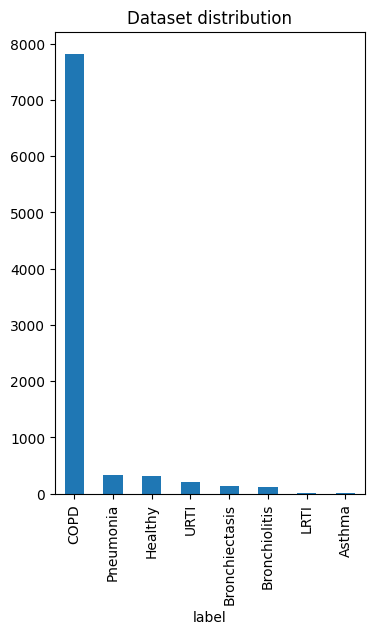

In [ ]:
plt.figure(figsize=(4,6))
dataset.label.value_counts().plot(kind='bar', title="Dataset distribution")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
train, test = train_test_split(dataset, test_size=0.2, random_state=42)
print("Train: %i" % len(train))
print("Test: %i" % len(test))

Train: 7172
Test: 1793


/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/158_1p4_Al_mc_AKGC417L.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/161_1b1_Pl_sc_Meditron.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/164_1b1_Ll_sc_Meditron.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/169_1b2_Ll_sc_Meditron.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/171_1b1_Al_sc_Meditron.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/191_2b2_Tc_mc_LittC2SE.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/103_2b2_Ar_mc_LittC2SE.wav
/content/drive/MyDrive/Colab Notebooks/ICBHI/ICBHI/ICBHI_final_database/115_1b1_Ar_sc_Meditron.wav


TypeError: melspectrogram() takes 0 positional arguments but 1 positional argument (and 3 keyword-only arguments) were given

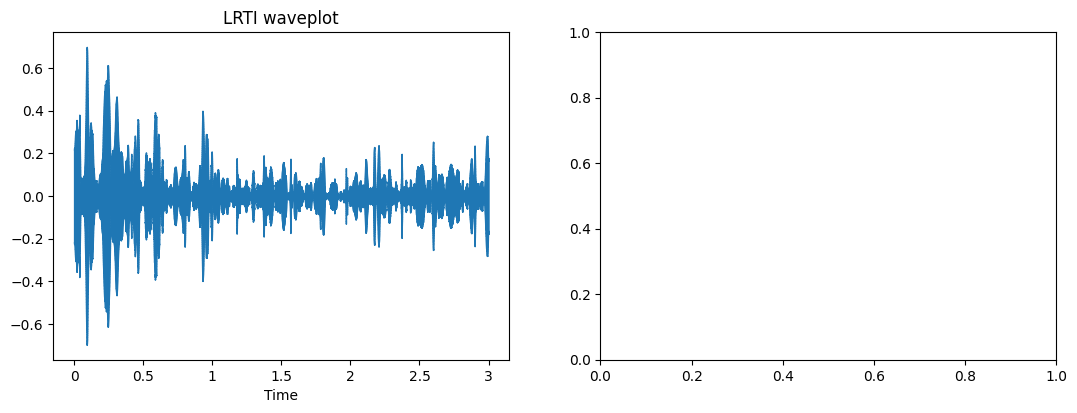

In [ ]:
plt.figure(figsize=(20,40))
idx = 0
for label in dataset.label.unique():
  y, sr = librosa.load(dataset[dataset.label==label].filename.iloc[1],duration=3)
  print(dataset[dataset.label==label].filename.iloc[1])

idx+=1
plt.subplot(8, 3, idx)
plt.title("%s waveplot" % label)
librosa.display.waveshow(y, sr=sr)

idx+=1
plt.subplot(8, 3, idx)
S = librosa.feature.melspectrogram(y, sr=sr, n_fft=2048, hop_length=512,n_mels=128)
S_DB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_DB, sr=sr, hop_length=512, x_axis='time',y_axis='mel')
plt.title("%s mel spectogram" % label)

idx+=1
mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
plt.subplot(8, 3, idx)
librosa.display.specshow(mfccs, x_axis='time')
plt.title("%s mfcc(Mel Spectrogram)" % label)
plt.show()

In [ ]:
def extract_features(audio_path,offset):
  y, sr = librosa.load(audio_path, offset=offset, duration=3)
  S = librosa.feature.melspectrogram(y, sr=sr, n_fft=2048,
                                     hop_length=512,
                                     n_mels=128)
  mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
  return mfccs

In [ ]:
from tqdm import tqdm

In [ ]:
x_train = []
x_test = []
for idx in tqdm(range(len(train))):
  x_train.append(extract_features(train.filename.iloc[idx],train.offset.iloc[idx]))
for idx in tqdm(range(len(test))):
  x_test.append(extract_features(test.filename.iloc[idx],test.offset.iloc[idx]))
x_test = (np.asarray(x_test))
x_train = (np.asarray(x_train))
print("X train:", train.shape)
print("X test:", test.shape)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical

In [ ]:
encoder = LabelEncoder()
encoder.fit(train.label)
y_train = encoder.transform(train.label)
y_test = encoder.transform(test.label)

class_weights = class_weight.compute_class_weight(class_weight='balanced',classes = np.unique(y_train),y=␣y_train)

In [ ]:
class_weights

In [ ]:
weight = {i : class_weights[i] for i in range(8)}
weight

In [ ]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print("X train:", x_train.shape)
print("Y train:", y_train.shape)
print("X test:", x_test.shape)
print("Y test:", y_test.shape)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Convolution2D, Conv2D, MaxPooling2D, GlobalAveragePooling2D

In [ ]:
model = Sequential()
model.add(Conv2D(filters=16, kernel_size=2, input_shape=(x_train.shape[1],x_train.shape[2],x_train.shape[3]), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv2D(filters=32, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv2D(filters=64, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv2D(filters=128, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.5))
model.add(GlobalAveragePooling2D())
model.add(Dense(len(encoder.classes_), activation='softmax'))
model.summary()

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [ ]:
history = model.fit(x_train, y_train,
                    batch_size=128,epochs=300,
                    validation_data=(x_test, y_test),
                    shuffle=True, class_weight=weight)

In [ ]:
plt.figure(figsize=[14,10])
plt.subplot(211)
plt.plot(history.history['loss'],'#d62728',linewidth=3.0)
plt.plot(history.history['val_loss'],'#1f77b4',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
plt.figure(figsize=[14,10])
plt.subplot(212)
plt.plot(history.history['accuracy'],'#d62728',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'#1f77b4',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

In [ ]:
scores = model.evaluate(x_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
predictions = model.predict(x_test, verbose=1)
y_true, y_pred = [],[]
classes = encoder.classes_
for idx, prediction in enumerate(predictions):
  y_true.append(classes[np.argmax(y_test[idx])])
  y_pred.append(classes[np.argmax(prediction)])
print(classification_report(y_pred, y_true))

In [ ]:
classes

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_true, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels=classes)
cm_display.plot()
plt.show()

In [ ]:
model_name = "lung.h5"
model.save(model_name)

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("lung.h5")

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
classify_file = "ICBHI//ICBHI_final_database//113_1b1_Ll_sc_Litt3200.wav"
test_x = []
test_x.append(extract_features(classify_file,0.5))
test_x = np.asarray(test_x)
test_x = test_x.reshape(test_x.shape[0], test_x.shape[1], test_x.shape[2], 1)
pred = model.predict(test_x,verbose=1)
print(pred)

In [ ]:
pred_class = model.predict(test_x)
index = np.argmax(pred_class, axis=1)
print(classes[index])

In [ ]:
actual = diagnosis.loc[diagnosis['ID'] == 113]
actual

In [ ]:
from tensorflow.keras.applications import vgg16, resnet
from tensorflow.keras.models import Model
import tensorflow.keras

In [ ]:
vgg = vgg16.VGG16(include_top=False, weights=None,
                  input_shape=(x_train.shape[1],x_train.shape[2],x_train.shape[3]))
output = vgg.layers[-1].output
output = keras.layers.Flatten()(output)
vgg_model = Model(vgg.input, output)

In [ ]:
import pandas as pd
pd.set_option('max_colwidth', -1)
layers = [(layer, layer.name, layer.trainable) for layer in vgg_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])

In [ ]:
modelvgg = Sequential()
modelvgg.add(vgg_model)
modelvgg.add(Dense(512, activation='relu'))
modelvgg.add(Dense(len(encoder.classes_), activation='softmax'))
modelvgg.summary()

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
modelvgg.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [ ]:
history_vgg = modelvgg.fit(x_train, y_train,
                           batch_size=128,
                           epochs=150,
                           validation_data=(x_test, y_test),
                           shuffle=True)

In [ ]:
plt.figure(figsize=[14,10])
plt.subplot(211)
plt.plot(history_vgg.history['loss'],'#d62728',linewidth=3.0)
plt.plot(history_vgg.history['val_loss'],'#1f77b4',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
plt.figure(figsize=[14,10])
plt.subplot(212)
plt.plot(history_vgg.history['accuracy'],'#d62728',linewidth=3.0)
plt.plot(history_vgg.history['val_accuracy'],'#1f77b4',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

In [ ]:
scores = modelvgg.evaluate(x_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [ ]:
predictions = modelvgg.predict(x_test, verbose=1)

y_true, y_pred = [],[]
classes = encoder.classes_
for idx, prediction in enumerate(predictions):
  y_true.append(classes[np.argmax(y_test[idx])])
  y_pred.append(classes[np.argmax(prediction)])
print(classification_report(y_pred, y_true))

In [ ]:
classes

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_true, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels=classes)
cm_display.plot()
plt.show()
